In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (10000, 14)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditSco

In [5]:
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape after cleaning: (10000, 14)

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
print(df.columns.tolist())

['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [8]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape after cleaning: (10000, 11)

Missing values:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Exited distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


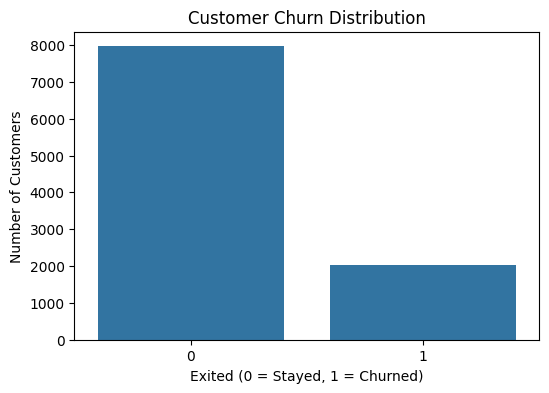

In [9]:
print("Exited distribution:")
print(df['Exited'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited')

plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

In [10]:
display(df.describe())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
df = pd.get_dummies(
    df,
    columns=['Geography', 'Gender'],
    drop_first=True
)

print("New shape:", df.shape)
display(df.head())

New shape: (10000, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 11)
Testing data: (2000, 11)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)

print("✅ Logistic Regression trained")
print("✅ Random Forest trained")
print("✅ Gradient Boosting trained")

✅ Logistic Regression trained
✅ Random Forest trained
✅ Gradient Boosting trained


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': (y_test, lr_predictions),
    'Random Forest': (y_test, rf_predictions),
    'Gradient Boosting': (y_test, gb_predictions)
}

results = []

for name, (actual, predicted) in models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(actual, predicted),
        'Precision': precision_score(actual, predicted),
        'Recall': recall_score(actual, predicted),
        'F1-Score': f1_score(actual, predicted)
    })

results_df = pd.DataFrame(results)

results_df = results_df.round(4)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.808,0.5891,0.1867,0.2836
1,Random Forest,0.863,0.7759,0.4595,0.5772
2,Gradient Boosting,0.870,0.7928,0.4889,0.6049


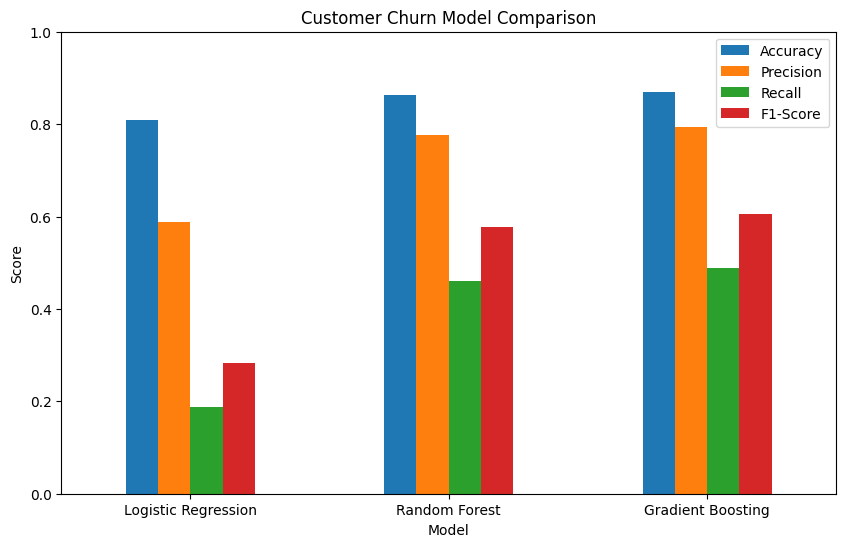

In [16]:
results_plot = results_df.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]]

results_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Customer Churn Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [17]:
best_model_name = results_df.loc[
    results_df['F1-Score'].idxmax(), 'Model'
]

print("Best Model based on F1-Score:", best_model_name)

Best Model based on F1-Score: Gradient Boosting


In [19]:
from sklearn.metrics import classification_report

if best_model_name == 'Logistic Regression':
    final_model = lr_model
    final_predictions = lr_predictions

elif best_model_name == 'Random Forest':
    final_model = rf_model
    final_predictions = rf_predictions

else:
    final_model = gb_model
    final_predictions = gb_predictions

print("Final Model:", best_model_name)

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_predictions,
    target_names=['Stayed', 'Churned']
))

Final Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [21]:
from sklearn.metrics import classification_report

if best_model_name == 'Logistic Regression':
    final_model = lr_model
    final_predictions = lr_predictions

elif best_model_name == 'Random Forest':
    final_model = rf_model
    final_predictions = rf_predictions

else:
    final_model = gb_model
    final_predictions = gb_predictions

print("Final Model:", best_model_name)

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_predictions,
    target_names=['Stayed', 'Churned']
))

Final Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



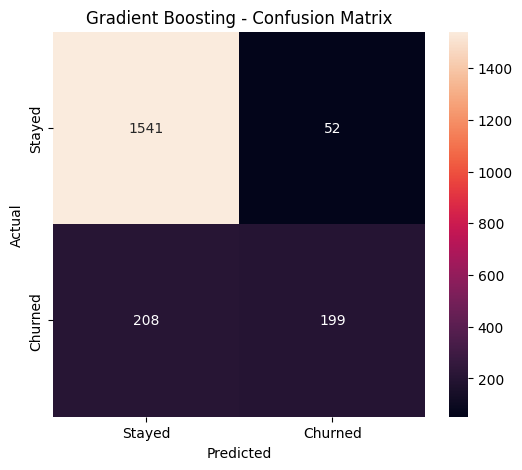

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Stayed', 'Churned'],
    yticklabels=['Stayed', 'Churned']
)

plt.title(f'{best_model_name} - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [23]:
customer = pd.DataFrame({
    'CreditScore': [600],
    'Age': [40],
    'Tenure': [3],
    'Balance': [60000],
    'NumOfProducts': [2],
    'HasCrCard': [1],
    'IsActiveMember': [0],
    'EstimatedSalary': [50000],
    'Geography_Germany': [1],
    'Geography_Spain': [0],
    'Gender_Male': [1]
})

prediction = final_model.predict(customer)[0]

if prediction == 1:
    print("⚠️ Prediction: Customer is likely to CHURN")
else:
    print("✅ Prediction: Customer is likely to STAY")

✅ Prediction: Customer is likely to STAY


In [24]:
import joblib

joblib.dump(final_model, "customer_churn_model.pkl")

print("✅ Final model saved successfully!")

✅ Final model saved successfully!


In [25]:
import os

if os.path.exists("customer_churn_model.pkl"):
    print("✅ customer_churn_model.pkl is ready")
else:
    print("❌ Model file not found")

✅ customer_churn_model.pkl is ready
